In [1]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns


# Load dataset
concerts = pl.read_parquet("../data/raw/concerts_raw.parquet")

# Inspect schema, row count, and missing values
print(f"Shape: {concerts.shape}")
print(concerts.schema)
print(concerts.null_count())

Shape: (1528, 11)
Schema({'id': String, 'name': String, 'city': String, 'state': String, 'venue': String, 'genre': String, 'sub_genre': String, 'event_date': String, 'min_price': Float64, 'max_price': Float64, 'currency': String})
shape: (1, 11)
┌─────┬──────┬──────┬───────┬───┬────────────┬───────────┬───────────┬──────────┐
│ id  ┆ name ┆ city ┆ state ┆ … ┆ event_date ┆ min_price ┆ max_price ┆ currency │
│ --- ┆ ---  ┆ ---  ┆ ---   ┆   ┆ ---        ┆ ---       ┆ ---       ┆ ---      │
│ u32 ┆ u32  ┆ u32  ┆ u32   ┆   ┆ u32        ┆ u32       ┆ u32       ┆ u32      │
╞═════╪══════╪══════╪═══════╪═══╪════════════╪═══════════╪═══════════╪══════════╡
│ 0   ┆ 0    ┆ 0    ┆ 0     ┆ … ┆ 0          ┆ 0         ┆ 0         ┆ 0        │
└─────┴──────┴──────┴───────┴───┴────────────┴───────────┴───────────┴──────────┘


In [2]:
concerts["min_price"].describe()

statistic,value
str,f64
"""count""",1528.0
"""null_count""",0.0
"""mean""",24.56305
"""std""",17.90958
"""min""",0.0
"""25%""",15.0
"""50%""",24.91
"""75%""",32.92
"""max""",235.0


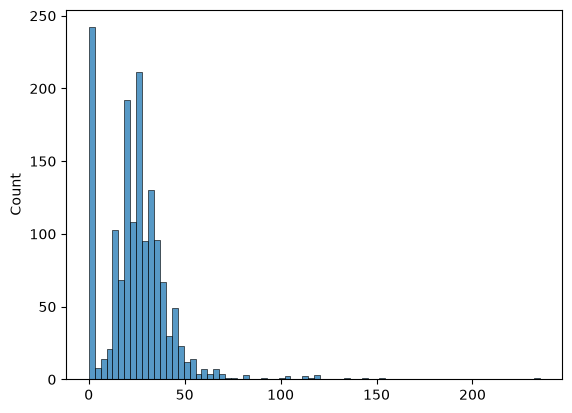

In [3]:
sns.histplot(concerts["min_price"].to_numpy())
plt.show() #checking to see the general shape

<Axes: ylabel='Count'>

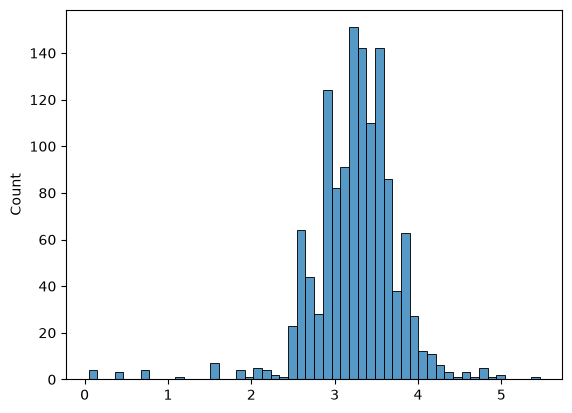

In [4]:
paid_concerts = concerts.filter(pl.col("min_price") > 0) #saw many 0 dollars that would mislead the regression
paid_concerts
sns.histplot((paid_concerts["min_price"].log().to_numpy())) #used log to get a standard distribution

In [5]:
paid_concerts.filter(pl.col("min_price") > 1).filter(pl.col("min_price") < 5) #checking to see if the outliers are flat admission fees

id,name,city,state,venue,genre,sub_genre,event_date,min_price,max_price,currency
str,str,str,str,str,str,str,str,f64,f64,str
"""rZ7HnEZ1AfGdo7""","""John Boerstler & Friends ft. S…","""Columbus""","""OH""","""Woodlands Tavern""","""Other""",null,"""2026-09-11""",1.5,1.5,"""USD"""
"""rZ7HnEZ1Afv3Jf""","""SMASH disco~glam~metal~punk-hi…","""Portland""","""OR""","""Dante's""","""Dance/Electronic""","""Dance Pop""","""2026-10-03""",1.05,1.05,"""USD"""
"""rZ7HnEZ1Af03_d""","""HOTWAX disco~glam~metal~punk~h…","""Portland""","""OR""","""Dante's""","""Dance/Electronic""","""Dance Pop""","""2026-10-02""",2.08,2.08,"""USD"""
"""rZ7HnEZ1Af03jS""","""HOTWAX disco~glam~metal~punk~h…","""Portland""","""OR""","""Dante's""","""Dance/Electronic""","""Dance Pop""","""2026-09-25""",2.08,2.08,"""USD"""
"""rZ7HnEZ1Af03jK""","""HOTWAX disco~glam~metal~punk~h…","""Portland""","""OR""","""Dante's""","""Dance/Electronic""","""Dance Pop""","""2026-09-18""",2.08,2.08,"""USD"""
…,…,…,…,…,…,…,…,…,…,…
"""rZ7HnEZ1A4ZwZS""","""Writers Night hosted by Steve …","""Nashville""","""TN""","""The Bluebird Cafe""","""Other""",null,"""2026-09-27""",4.86,4.86,"""USD"""
"""rZ7HnEZ1A4Zt4d""","""Americana Music Association Pr…","""Nashville""","""TN""","""The Bluebird Cafe""","""Country""","""Country""","""2026-09-17""",4.86,4.86,"""USD"""
"""rZ7HnEZ1Af03fK""","""HOTWAX disco~glam~metal~punk~h…","""Portland""","""OR""","""Dante's""","""Dance/Electronic""","""Dance Pop""","""2026-09-11""",2.08,2.08,"""USD"""


In [6]:
paid_concerts.filter(pl.col("min_price") >= 5).group_by("genre").agg([pl.len().alias("count"),pl.col("min_price").median().alias("median_price"),pl.col("min_price").mean().alias("mean_price")]).sort("count", descending=True) 
#checking to see if genre has a difference in price

genre,count,median_price,mean_price
str,u32,f64,f64
"""Alternative""",228,24.47,27.613684
"""Rock""",223,26.15,28.625919
"""Jazz""",168,35.65,36.560238
"""Other""",128,23.575,25.37625
"""Country""",97,25.16,25.654948
…,…,…,…
"""Blues""",22,23.0,23.98
"""Religious""",11,27.62,29.819091
"""Reggae""",8,28.455,28.04875


In [7]:
paid_concerts = paid_concerts.with_columns(pl.col("city").str.strip_chars()) #combined duplicate cities
paid_concerts.filter(pl.col("min_price") >= 5).group_by("city").agg([pl.len().alias("count"),pl.col("min_price").median().alias("median_price")]).sort("count", descending=True) #checking if cost of living in different cities affect cost


city,count,median_price
str,u32,f64
"""New Orleans""",139,27.98
"""Nashville""",124,25.72
"""New York""",117,35.46
"""Columbus""",94,25.89
"""Seattle""",93,25.49
…,…,…
"""Kansas City""",5,27.62
"""Austin""",3,28.61
"""Houston""",1,36.29


In [8]:
paid_concerts = paid_concerts.with_columns(
    pl.col("event_date").str.to_date("%Y-%m-%d").alias("event_date")
).with_columns(
    pl.col("event_date").dt.weekday().alias("day_of_week"),
    pl.col("event_date").dt.month().alias("month"),
    pl.col("event_date").dt.weekday().is_in([5, 6, 7]).alias("is_weekend")
) #separated day of week and month (day of week goes from monday(1) - sunday(7))
paid_concerts

id,name,city,state,venue,genre,sub_genre,event_date,min_price,max_price,currency,day_of_week,month,is_weekend
str,str,str,str,str,str,str,date,f64,f64,str,i8,i8,bool
"""rZ7HnEZ1Af1Z47""","""Society Of The Silver Cross To…","""Seattle""","""WA""","""Tractor""","""Rock""","""Alternative Rock""",2026-09-24,18.9,18.9,"""USD""",4,9,false
"""rZ7HnEZ1A4ZtoK""","""An Evening with Stephanie Urbi…","""Nashville""","""TN""","""The Bluebird Cafe""","""Country""","""Honky Tonk""",2026-09-15,27.63,27.63,"""USD""",2,9,false
"""rZ7HnEZ1A4ZNPd""","""Manic Outburst, Condition Crit…","""Detroit""","""MI""","""TSDMAAC""","""Metal""","""Thrash & Speed""",2026-09-10,21.36,21.36,"""USD""",4,9,false
"""rZ7HnEZ1AfFk-V""","""Cristina Vane w/ Kate Dinsmore…","""Seattle""","""WA""","""Tractor""","""Folk""","""Americana""",2026-09-19,25.08,31.26,"""USD""",6,9,true
"""rZ7HnEZ1Afkfff""","""YHWH Nailgun, Nudo""","""Detroit""","""MI""","""TSDMAAC (Catacombs)""","""Alternative""","""Alternative""",2026-09-19,32.92,32.92,"""USD""",6,9,true
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""rZ7HnEZ1A4ZJPS""","""Ben Musser | Sasha Dobson""","""New York""","""NY""","""Bowery Palace""","""Folk""","""Americana""",2026-09-09,18.78,18.78,"""USD""",3,9,false
"""rZ7HnEZ1Af13uf""","""Girl of Glass, Thus Spoke Zara…","""Detroit""","""MI""","""TSDMAAC""","""Metal""","""Heavy Metal""",2026-11-15,21.72,21.72,"""USD""",7,11,true
"""rZ7HnEZ1AfavjV""","""The Grammy Winning Hot 8 Brass…","""New Orleans""","""LA""","""Howlin' Wolf""","""Jazz""","""Jazz""",2026-10-25,24.94,24.94,"""USD""",7,10,true


In [9]:
weekend_shows = paid_concerts.with_columns(pl.col("day_of_week").is_in([5, 6, 7]).alias("is_weekend"))
weekend_shows.group_by("is_weekend").agg([pl.len().alias("count"),pl.col("min_price").median().alias("median_price")]) #checking if weekend influenced price (does not)

is_weekend,count,median_price
bool,u32,f64
false,581,26.46
true,716,26.78


In [10]:
weekday_shows = paid_concerts.with_columns(~pl.col("day_of_week").is_in([5, 6, 7]).alias("is_weekend"))

In [11]:
unpaid_concerts = concerts.filter(pl.col("min_price") == 0) #save this for later

In [12]:
paid_concerts.write_parquet("cleaned_concerts.parquet")

In [13]:
# 1. Identify cities and genres with at least 15 shows
frequent_cities = (
    paid_concerts
    .group_by("city")
    .len()
    .filter(pl.col("len") >= 15)
    .select("city")
    .to_series()
    .to_list()
)

frequent_genres = (
    paid_concerts
    .group_by("genre")
    .len()
    .filter(pl.col("len") >= 15)
    .select("genre")
    .to_series()
    .to_list()
)

# 2. Collapse infrequent values into "Other"
paid_concerts = paid_concerts.with_columns([
    pl.when(pl.col("city").is_in(frequent_cities))
      .then(pl.col("city"))
      .otherwise(pl.lit("Other"))
      .alias("city_grouped"),
      
    pl.when(pl.col("genre").is_in(frequent_genres))
      .then(pl.col("genre"))
      .otherwise(pl.lit("Other"))
      .alias("genre_grouped")
])

# 3. Inspect category counts
print("Grouped Cities:", paid_concerts["city_grouped"].n_unique())
print("Grouped Genres:", paid_concerts["genre_grouped"].n_unique())

Grouped Cities: 21
Grouped Genres: 13


In [14]:
import numpy as np
import polars as pl
from sklearn.linear_model import Ridge
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# 1. Prepare target vector (log-transformed to stabilize price skew)
y = np.log(paid_concerts["min_price"].to_numpy())

# 2. Select features and encode categoricals
cat_cols = ["genre_grouped", "city_grouped"]
num_cols = ["is_weekend"]

encoder = OneHotEncoder(drop="first", sparse_output=False)
X_cat = encoder.fit_transform(paid_concerts.select(cat_cols).to_numpy())
cat_feature_names = encoder.get_feature_names_out(cat_cols).tolist()

# Convert boolean flag to binary (0/1) float array
X_num = paid_concerts.select(num_cols).to_numpy().astype(float)

# Combine into design matrix X
X = np.hstack([X_cat, X_num])
feature_names = cat_feature_names + num_cols

# 3. Train/Test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# 4. Fit Ridge regression model
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

# 5. Predict and back-transform from log space to real dollars ($)
y_pred_log = model.predict(X_test)
y_pred_dollars = np.exp(y_pred_log)
y_test_dollars = np.exp(y_test)

# 6. Evaluate baseline performance
rmse = root_mean_squared_error(y_test_dollars, y_pred_dollars)
mae = mean_absolute_error(y_test_dollars, y_pred_dollars)

print(f"Test Set Evaluation:")
print(f"  RMSE: ${rmse:.2f}")
print(f"  MAE:  ${mae:.2f}\n")

# 7. Inspect top price-driving features
coef_df = pl.DataFrame({
    "feature": feature_names,
    "weight": model.coef_
}).sort("weight", descending=True)

print("Top 5 Positive Price Drivers:")
print(coef_df.head(5))

print("\nTop 5 Negative Price Drivers:")
print(coef_df.tail(5))

Test Set Evaluation:
  RMSE: $18.60
  MAE:  $9.38

Top 5 Positive Price Drivers:
shape: (5, 2)
┌─────────────────────────┬──────────┐
│ feature                 ┆ weight   │
│ ---                     ┆ ---      │
│ str                     ┆ f64      │
╞═════════════════════════╪══════════╡
│ city_grouped_Washington ┆ 0.461699 │
│ city_grouped_San Diego  ┆ 0.38713  │
│ genre_grouped_Jazz      ┆ 0.377234 │
│ genre_grouped_R&B       ┆ 0.312384 │
│ genre_grouped_Metal     ┆ 0.149984 │
└─────────────────────────┴──────────┘

Top 5 Negative Price Drivers:
shape: (5, 2)
┌──────────────────────────┬───────────┐
│ feature                  ┆ weight    │
│ ---                      ┆ ---       │
│ str                      ┆ f64       │
╞══════════════════════════╪═══════════╡
│ city_grouped_Pittsburgh  ┆ -0.285956 │
│ city_grouped_Columbus    ┆ -0.338486 │
│ city_grouped_Denver      ┆ -0.354845 │
│ city_grouped_Los Angeles ┆ -0.538846 │
│ city_grouped_Portland    ┆ -0.550887 │
└────────────────────

In [15]:
# Build a comparison DataFrame for the test split
test_indices = np.array(range(len(paid_concerts)))[X_test.shape[0]:]  # test split alignment

test_results = pl.DataFrame({
    "actual_price": y_test_dollars,
    "predicted_price": y_pred_dollars,
    "abs_error": np.abs(y_test_dollars - y_pred_dollars),
    "squared_error": (y_test_dollars - y_pred_dollars) ** 2,
}).sort("abs_error", descending=True)

print("Top 5 Worst Predictions:")
print(test_results.head(5))

Top 5 Worst Predictions:
shape: (5, 4)
┌──────────────┬─────────────────┬────────────┬───────────────┐
│ actual_price ┆ predicted_price ┆ abs_error  ┆ squared_error │
│ ---          ┆ ---             ┆ ---        ┆ ---           │
│ f64          ┆ f64             ┆ f64        ┆ f64           │
╞══════════════╪═════════════════╪════════════╪═══════════════╡
│ 235.0        ┆ 40.950409       ┆ 194.049591 ┆ 37655.243827  │
│ 154.49       ┆ 28.76828        ┆ 125.72172  ┆ 15805.950833  │
│ 115.49       ┆ 45.251947       ┆ 70.238053  ┆ 4933.384051   │
│ 100.4        ┆ 31.333314       ┆ 69.066686  ┆ 4770.207153   │
│ 90.91        ┆ 24.587234       ┆ 66.322766  ┆ 4398.709325   │
└──────────────┴─────────────────┴────────────┴───────────────┘


In [16]:
print(coef_df.head(10))
print(coef_df.tail(10))

shape: (10, 2)
┌───────────────────────────┬──────────┐
│ feature                   ┆ weight   │
│ ---                       ┆ ---      │
│ str                       ┆ f64      │
╞═══════════════════════════╪══════════╡
│ city_grouped_Washington   ┆ 0.461699 │
│ city_grouped_San Diego    ┆ 0.38713  │
│ genre_grouped_Jazz        ┆ 0.377234 │
│ genre_grouped_R&B         ┆ 0.312384 │
│ genre_grouped_Metal       ┆ 0.149984 │
│ genre_grouped_World       ┆ 0.127993 │
│ genre_grouped_Rock        ┆ 0.115908 │
│ genre_grouped_Hip-Hop/Rap ┆ 0.10291  │
│ genre_grouped_Pop         ┆ 0.099884 │
│ city_grouped_Other        ┆ 0.041043 │
└───────────────────────────┴──────────┘
shape: (10, 2)
┌───────────────────────────┬───────────┐
│ feature                   ┆ weight    │
│ ---                       ┆ ---       │
│ str                       ┆ f64       │
╞═══════════════════════════╪═══════════╡
│ city_grouped_Dallas       ┆ -0.175328 │
│ city_grouped_New Orleans  ┆ -0.178182 │
│ city_grouped_Phila

In [17]:
paid_concerts.write_parquet("cleaned_concerts.parquet")

In [18]:
import numpy as np
import polars as pl
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.preprocessing import OneHotEncoder

# 1. Train/Test split directly on the Polars DataFrame (80/20)
shuffled_df = paid_concerts.sample(fraction=1.0, shuffle=True, seed=42)
split_idx = int(0.8 * len(shuffled_df))

train_df = shuffled_df[:split_idx]
test_df = shuffled_df[split_idx:]

# 2. Compute median ticket price per artist on training set only (prevents data leakage)
artist_tiers = (
    train_df
    .group_by("name")
    .agg(pl.col("min_price").median().alias("artist_tier_price"))
)

overall_train_median = train_df["min_price"].median()

# Join artist tier back and impute unseen test artists with the overall median
train_df = train_df.join(artist_tiers, on="name", how="left")
test_df = test_df.join(artist_tiers, on="name", how="left").with_columns(
    pl.col("artist_tier_price").fill_null(overall_train_median)
)

# 3. Define target vectors (log-transformed)
y_train = np.log(train_df["min_price"].to_numpy())
y_test = np.log(test_df["min_price"].to_numpy())

# 4. One-Hot Encode categoricals (fit on train, transform test)
cat_cols = ["genre_grouped", "city_grouped"]
encoder = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")

X_train_cat = encoder.fit_transform(train_df.select(cat_cols).to_numpy())
X_test_cat = encoder.transform(test_df.select(cat_cols).to_numpy())

# 5. Extract numeric features: log(artist_tier_price) and is_weekend
X_train_num = np.column_stack([
    np.log(train_df["artist_tier_price"].to_numpy()),
    train_df["is_weekend"].to_numpy().astype(float)
])

X_test_num = np.column_stack([
    np.log(test_df["artist_tier_price"].to_numpy()),
    test_df["is_weekend"].to_numpy().astype(float)
])

# Assemble full design matrices
X_train = np.hstack([X_train_cat, X_train_num])
X_test = np.hstack([X_test_cat, X_test_num])

# 6. Fit Ridge Regression model
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

# 7. Predict and back-transform to real dollars ($)
y_pred_dollars = np.exp(model.predict(X_test))
y_test_dollars = np.exp(y_test)

# 8. Evaluate new performance
new_rmse = root_mean_squared_error(y_test_dollars, y_pred_dollars)
new_mae = mean_absolute_error(y_test_dollars, y_pred_dollars)

print(f"Updated Model (with Artist Tiers):")
print(f"  RMSE: ${new_rmse:.2f}")
print(f"  MAE:  ${new_mae:.2f}")

Updated Model (with Artist Tiers):
  RMSE: $14.25
  MAE:  $7.36


In [21]:
test_results = pl.DataFrame({
    "actual_price": y_test_dollars,
    "predicted_price": y_pred_dollars,
    "abs_error": np.abs(y_test_dollars - y_pred_dollars),
    "squared_error": (y_test_dollars - y_pred_dollars) ** 2,
}).sort("abs_error", descending=True)

print("Top 5 Worst Predictions (with Artist Tiers):")
print(test_results.head(5))

Top 5 Worst Predictions (with Artist Tiers):
shape: (5, 4)
┌──────────────┬─────────────────┬────────────┬───────────────┐
│ actual_price ┆ predicted_price ┆ abs_error  ┆ squared_error │
│ ---          ┆ ---             ┆ ---        ┆ ---           │
│ f64          ┆ f64             ┆ f64        ┆ f64           │
╞══════════════╪═════════════════╪════════════╪═══════════════╡
│ 154.49       ┆ 26.226725       ┆ 128.263275 ┆ 16451.467737  │
│ 144.47       ┆ 26.035324       ┆ 118.434676 ┆ 14026.772482  │
│ 68.05        ┆ 26.723712       ┆ 41.326288  ┆ 1707.862061   │
│ 81.5         ┆ 40.929421       ┆ 40.570579  ┆ 1645.971905   │
│ 62.95        ┆ 25.859041       ┆ 37.090959  ┆ 1375.739224   │
└──────────────┴─────────────────┴────────────┴───────────────┘


In [19]:
print("Unique venues:", paid_concerts["venue"].n_unique())
print(paid_concerts.group_by("venue").len().sort("len", descending=True).head(10))

Unique venues: 127
shape: (10, 2)
┌─────────────────────────┬─────┐
│ venue                   ┆ len │
│ ---                     ┆ --- │
│ str                     ┆ u32 │
╞═════════════════════════╪═════╡
│ Blue Note Los Angeles   ┆ 42  │
│ TSDMAAC                 ┆ 42  │
│ Nikki Lopez Philly      ┆ 42  │
│ Rumba Cafe              ┆ 41  │
│ Will's Pub              ┆ 38  │
│ The Bluebird Cafe       ┆ 37  │
│ Snug Harbor Jazz Bistro ┆ 36  │
│ Tractor                 ┆ 34  │
│ Club Cafe               ┆ 32  │
│ Dante's                 ┆ 29  │
└─────────────────────────┴─────┘


In [20]:
import numpy as np
import polars as pl
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.preprocessing import OneHotEncoder

# 1. Train/Test split directly on the Polars DataFrame (80/20)
shuffled_df = paid_concerts.sample(fraction=1.0, shuffle=True, seed=42)
split_idx = int(0.8 * len(shuffled_df))

train_df = shuffled_df[:split_idx]
test_df = shuffled_df[split_idx:]

overall_train_median = train_df["min_price"].median()

# 2. Artist Tier Target Encoding (computed on train only)
artist_tiers = (
    train_df
    .group_by("name")
    .agg(pl.col("min_price").median().alias("artist_tier_price"))
)

# 3. Venue Tier Target Encoding (computed on train only)
venue_tiers = (
    train_df
    .group_by("venue")
    .agg(pl.col("min_price").median().alias("venue_tier_price"))
)

# 4. Join target encodings back and impute unseen entities with overall train median
train_df = (
    train_df
    .join(artist_tiers, on="name", how="left")
    .join(venue_tiers, on="venue", how="left")
    .with_columns([
        pl.col("artist_tier_price").fill_null(overall_train_median),
        pl.col("venue_tier_price").fill_null(overall_train_median)
    ])
)

test_df = (
    test_df
    .join(artist_tiers, on="name", how="left")
    .join(venue_tiers, on="venue", how="left")
    .with_columns([
        pl.col("artist_tier_price").fill_null(overall_train_median),
        pl.col("venue_tier_price").fill_null(overall_train_median)
    ])
)

# 5. Define log targets
y_train = np.log(train_df["min_price"].to_numpy())
y_test = np.log(test_df["min_price"].to_numpy())

# 6. One-Hot Encode categorical variables
cat_cols = ["genre_grouped", "city_grouped"]
encoder = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")

X_train_cat = encoder.fit_transform(train_df.select(cat_cols).to_numpy())
X_test_cat = encoder.transform(test_df.select(cat_cols).to_numpy())

# 7. Stack continuous log-price features and weekend indicator
X_train_num = np.column_stack([
    np.log(train_df["artist_tier_price"].to_numpy()),
    np.log(train_df["venue_tier_price"].to_numpy()),
    train_df["is_weekend"].to_numpy().astype(float)
])

X_test_num = np.column_stack([
    np.log(test_df["artist_tier_price"].to_numpy()),
    np.log(test_df["venue_tier_price"].to_numpy()),
    test_df["is_weekend"].to_numpy().astype(float)
])

X_train = np.hstack([X_train_cat, X_train_num])
X_test = np.hstack([X_test_cat, X_test_num])

# 8. Train Ridge Regressor
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

# 9. Evaluate in real dollars ($)
y_pred_dollars = np.exp(model.predict(X_test))
y_test_dollars = np.exp(y_test)

final_rmse = root_mean_squared_error(y_test_dollars, y_pred_dollars)
final_mae = mean_absolute_error(y_test_dollars, y_pred_dollars)

print(f"Updated Model (Artist + Venue Tiers):")
print(f"  RMSE: ${final_rmse:.2f}")
print(f"  MAE:  ${final_mae:.2f}")

Updated Model (Artist + Venue Tiers):
  RMSE: $14.24
  MAE:  $7.35


In [21]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import OrdinalEncoder

# 1. Prepare raw categorical columns directly (no high-cardinality one-hot explosion)
cat_features = ["genre_grouped", "city_grouped"]
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

X_train_cat_ord = encoder.fit_transform(train_df.select(cat_features).to_numpy())
X_test_cat_ord = encoder.transform(test_df.select(cat_features).to_numpy())

# 2. Combine ordinal categoricals with continuous tier prices and calendar flags
X_train_tree = np.column_stack([
    X_train_cat_ord,
    train_df["artist_tier_price"].to_numpy(),
    train_df["venue_tier_price"].to_numpy(),
    train_df["is_weekend"].to_numpy().astype(float),
    train_df["month"].to_numpy().astype(float),
    train_df["day_of_week"].to_numpy().astype(float),
])

X_test_tree = np.column_stack([
    X_test_cat_ord,
    test_df["artist_tier_price"].to_numpy(),
    test_df["venue_tier_price"].to_numpy(),
    test_df["is_weekend"].to_numpy().astype(float),
    test_df["month"].to_numpy().astype(float),
    test_df["day_of_week"].to_numpy().astype(float),
])

# 3. Fit Gradient Boosted Trees with native categorical feature support
tree_model = HistGradientBoostingRegressor(
    categorical_features=[0, 1],  # genre_grouped and city_grouped indices
    random_state=42,
    max_iter=200,
    learning_rate=0.08
)
tree_model.fit(X_train_tree, y_train)

# 4. Predict and evaluate
y_pred_tree = np.exp(tree_model.predict(X_test_tree))

tree_rmse = root_mean_squared_error(y_test_dollars, y_pred_tree)
tree_mae = mean_absolute_error(y_test_dollars, y_pred_tree)

print(f"HistGradientBoosting Performance:")
print(f"  RMSE: ${tree_rmse:.2f}")
print(f"  MAE:  ${tree_mae:.2f}")

HistGradientBoosting Performance:
  RMSE: $14.23
  MAE:  $7.43


In [23]:
artist_counts = (
    train_df
    .group_by("name")
    .len()
    .rename({"len": "artist_event_count"})
)

train_df = train_df.join(artist_counts, on="name", how="left")
test_df = test_df.join(artist_counts, on="name", how="left").with_columns(
    pl.col("artist_event_count").fill_null(1)
)
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

# --- 1. Ridge Regression with Event Count ---
cat_cols = ["genre_grouped", "city_grouped"]
ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
X_train_ohe = ohe.fit_transform(train_df.select(cat_cols).to_numpy())
X_test_ohe = ohe.transform(test_df.select(cat_cols).to_numpy())

# Stack continuous tier prices, event count, and weekend flag
X_train_ridge = np.column_stack([
    X_train_ohe,
    np.log(train_df["artist_tier_price"].to_numpy()),
    np.log(train_df["venue_tier_price"].to_numpy()),
    np.log1p(train_df["artist_event_count"].to_numpy().astype(float)),
    train_df["is_weekend"].to_numpy().astype(float)
])

X_test_ridge = np.column_stack([
    X_test_ohe,
    np.log(test_df["artist_tier_price"].to_numpy()),
    np.log(test_df["venue_tier_price"].to_numpy()),
    np.log1p(test_df["artist_event_count"].to_numpy().astype(float)),
    test_df["is_weekend"].to_numpy().astype(float)
])

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_ridge, y_train)
y_pred_ridge = np.exp(ridge_model.predict(X_test_ridge))

print("Ridge with Artist Event Count:")
print(f"  RMSE: ${root_mean_squared_error(y_test_dollars, y_pred_ridge):.2f}")
print(f"  MAE:  ${mean_absolute_error(y_test_dollars, y_pred_ridge):.2f}\n")

# --- 2. HistGradientBoostingRegressor with Event Count ---
ord_enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_train_ord = ord_enc.fit_transform(train_df.select(cat_cols).to_numpy())
X_test_ord = ord_enc.transform(test_df.select(cat_cols).to_numpy())

X_train_tree = np.column_stack([
    X_train_ord,
    train_df["artist_tier_price"].to_numpy(),
    train_df["venue_tier_price"].to_numpy(),
    train_df["artist_event_count"].to_numpy().astype(float),
    train_df["is_weekend"].to_numpy().astype(float),
    train_df["month"].to_numpy().astype(float),
    train_df["day_of_week"].to_numpy().astype(float),
])

X_test_tree = np.column_stack([
    X_test_ord,
    test_df["artist_tier_price"].to_numpy(),
    test_df["venue_tier_price"].to_numpy(),
    test_df["artist_event_count"].to_numpy().astype(float),
    test_df["is_weekend"].to_numpy().astype(float),
    test_df["month"].to_numpy().astype(float),
    test_df["day_of_week"].to_numpy().astype(float),
])

gbdt_model = HistGradientBoostingRegressor(
    categorical_features=[0, 1],
    random_state=42,
    max_iter=200,
    learning_rate=0.08
)
gbdt_model.fit(X_train_tree, y_train)
y_pred_gbdt = np.exp(gbdt_model.predict(X_test_tree))

print("HistGradientBoosting with Artist Event Count:")
print(f"  RMSE: ${root_mean_squared_error(y_test_dollars, y_pred_gbdt):.2f}")
print(f"  MAE:  ${mean_absolute_error(y_test_dollars, y_pred_gbdt):.2f}")

Ridge with Artist Event Count:
  RMSE: $14.22
  MAE:  $7.36

HistGradientBoosting with Artist Event Count:
  RMSE: $14.23
  MAE:  $7.46


In [24]:
import joblib

pipeline_artifacts = {
    "model": ridge_model,
    "encoder": ohe,
    "artist_tiers": artist_tiers,
    "venue_tiers": venue_tiers,
    "overall_median": overall_train_median,
}

joblib.dump(pipeline_artifacts, "concert_price_model.joblib")
print("Saved pipeline artifacts to concert_price_model.joblib")

Saved pipeline artifacts to concert_price_model.joblib


In [25]:
train_df.write_parquet("train_engineered.parquet")
test_df.write_parquet("test_engineered.parquet")
print("Exported parquet datasets.")

Exported parquet datasets.
